# Hyperparameter Tuning: Optimizing Model Performance

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Danselem/brics_astro/blob/main/Week6/04_parameter_tuning.ipynb)

Machine learning models often have parameters that are **not learned from the data** but are set by the user *before* training begins. These are called **hyperparameters**. The choice of hyperparameters can significantly impact a model's performance.

For example, in the K-Nearest Neighbors (KNN) model, the number of neighbors (`n_neighbors`) is a hyperparameter. Choosing `n_neighbors=3` might work well, but would `n_neighbors=5` or `n_neighbors=10` yield better results?

**Hyperparameter tuning** is the process of finding the optimal set of hyperparameters for a given model and dataset. The goal is to maximize the model's performance on *unseen* data.

A common approach is **Grid Search**. This involves:

1.  Defining a grid of possible values for each hyperparameter you want to tune.
2.  Training and evaluating the model for every possible combination of hyperparameter values in the grid.
3.  Identifying the combination that yields the best performance (typically measured using cross-validation on the training data).

Scikit-learn provides tools like `GridSearchCV` to automate this process. It systematically explores the grid and handles the cross-validation to find the best parameters.

---

**中文**

# 超参数调优：优化模型性能

[![在 Colab 中打开](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Danselem/brics_astro/blob/main/Week6/04_parameter_tuning.ipynb)

机器学习模型通常具有**不是从数据中学习**的参数，而是由用户“在”训练开始之前设置的。这些称为**超参数**。超参数的选择可以显着影响模型的性能。

例如，在 K 最近邻 (KNN) 模型中，邻居数量 (`n_neighbors`) 是一个超参数。选择`n_neighbors=3` 可能效果很好，但是`n_neighbors=5` 或`n_neighbors=10` 会产生更好的结果吗？

**超参数调整**是为给定模型和数据集找到最佳超参数集的过程。目标是最大限度地提高模型在“看不见的”数据上的性能。

常见的方法是**网格搜​​索**。这涉及：

1. 为要调整的每个超参数定义可能值的网格。
2. 针对网格中超参数值的每种可能组合来训练和评估模型。
3. 确定产生最佳性能的组合（通常使用训练数据的交叉验证来衡量）。

Scikit-learn 提供了 `GridSearchCV` 等工具来自动化此过程。它系统地探索网格并处理交叉验证以找到最佳参数。


In [37]:
# import the modules

import time
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
import matplotlib.pyplot as plt

**Note:**
If you are running this jupyter notebook from Colab, then run the next cell by pressing `SHIFT+ENTER` to install the required packages for this notebook. Otherwise, skip the next cell.

---

**中文**

**注：**
如果您从 Colab 运行此 jupyter 笔记本，请按 `SHIFT+ENTER` 运行下一个单元以安装此笔记本所需的软件包。否则，跳过下一个单元格。


In [ ]:
!mkdir -p data
!wget -P data https://raw.githubusercontent.com/Danselem/brics_astro/main/Week6/data/sdss_photoz.npy

In [ ]:
import numpy as np
import pandas as pd
import os

# Paths
input_path = 'data/sdss_photoz.npy'
output_path = 'data/sdss_photoz_clean.csv'

# Load structured array
data = np.load(input_path)

# Convert magnitude fields to float64
u = data['u'].astype('float64')
g = data['g'].astype('float64')
r = data['r'].astype('float64')
i = data['i'].astype('float64')
z = data['z'].astype('float64')

# Step 1: Remove non-finite values
finite_mask = (
    np.isfinite(u) &
    np.isfinite(g) &
    np.isfinite(r) &
    np.isfinite(i) &
    np.isfinite(z)
)

# Step 2: Filter for valid SDSS magnitude range
valid_range_mask = (
    (u > 10) & (u < 40) &
    (g > 10) & (g < 40) &
    (r > 10) & (r < 40) &
    (i > 10) & (i < 40) &
    (z > 10) & (z < 40)
)

# Step 3: Remove unwanted specClass values
excluded_spec_classes = [60, 61, 62, 63]
spec_mask = ~np.isin(data['specClass'], excluded_spec_classes)

# Combine all masks
final_mask = finite_mask & valid_range_mask & spec_mask

# Apply the mask
data_clean = data[final_mask]

# Convert to DataFrame
df = pd.DataFrame({
    'u': data_clean['u'],
    'g': data_clean['g'],
    'r': data_clean['r'],
    'i': data_clean['i'],
    'z': data_clean['z'],
    'specClass': data_clean['specClass'],
    'redshift': data_clean['redshift'],
    'redshifterr': data_clean['redshifterr']
})

df = df[(df['redshift']>0) & (df['redshift']< 2.5)]

# Save to CSV
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

In [15]:
# Load the preprocessed data
df = pd.read_csv("data/sdss_photoz_clean.csv")

df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Features: color indices; Target: redshift
X = df[['u-g', 'g-r', 'r-i', 'i-z']].values
y = df['redshift'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Cross-Validation with KFold and Grid Search

### What is Cross-Validation?

Cross-validation is a model validation technique used to assess how a predictive model generalizes to an independent dataset. It helps detect issues like overfitting or underfitting by splitting the data into training and validation sets multiple times in a systematic way.

---

### KFold Cross-Validation

**KFold** (K-Folds cross-validation) divides the dataset into *K* equal-sized folds. The model is trained on *K-1* folds and validated on the remaining fold. This process is repeated *K* times so that each fold serves as a validation set once.

**How it works:**

- Split data into `K` subsets (folds)
- Train the model on `K-1` folds
- Validate on the remaining fold
- Repeat the process for all `K` folds
- Average the performance metrics across all folds

**Advantages:**

- More robust estimate of model performance
- Reduces variance compared to a single train-test split
- Ensures that every data point is used for validation

---

### Grid Search with Cross-Validation

**GridSearchCV** performs an exhaustive search over a specified parameter grid by:

1. Trying all possible combinations of hyperparameters.
2. Performing cross-validation (e.g., using KFold) for each combination.
3. Selecting the combination that yields the best cross-validated performance.

**Key Parameters:**

- `param_grid`: A dictionary defining which parameters and values to try.
- `cv`: The cross-validation strategy (e.g., `KFold(n_splits=5)`).
- `scoring`: A string or dictionary of scoring metrics (e.g., `'r2'`, `'neg_mean_squared_error'`).
- `refit`: Which scoring metric to use for choosing the best model.

---

For more on cross validation, check out the sklearn documentation: <https://scikit-learn.org/stable/modules/cross_validation.html>

---

**中文**

## 使用 KFold 和网格搜索进行交叉验证

### 什么是交叉验证？

交叉验证是一种模型验证技术，用于评估预测模型如何推广到独立数据集。它通过系统地将数据多次拆分为训练集和验证集来帮助检测过度拟合或欠拟合等问题。

---

### KFold 交叉验证

**KFold**（K 折叠交叉验证）将数据集划分为 *K* 个大小相等的折叠。该模型在 *K-1* 折叠上进行训练，并在剩余折叠上进行验证。此过程重复 *K* 次，以便每个折叠都用作验证集一次。

**它是如何工作的：**

- 将数据拆分为`K`子集（折叠）
- 在`K-1` 折叠上训练模型
- 验证剩余的折叠
- 对所有`K` 折叠重复此过程
- 平均所有折叠的性能指标

**优点：**

- 更稳健地估计模型性能
- 与单个训练测试分割相比，减少了方差
- 确保每个数据点都用于验证

---

### 带有交叉验证的网格搜索

**GridSearchCV** 通过以下方式对指定参数网格执行详尽搜索：

1. 尝试所有可能的超参数组合。
2. 对每个组合执行交叉验证（例如，使用 KFold）。
3. 选择产生最佳交叉验证性能的组合。

**关键参数：**

- `param_grid`：定义要尝试哪些参数和值的字典。
- `cv`：交叉验证策略（例如，`KFold(n_splits=5)`）。
- `scoring`：评分指标的字符串或字典（例如，`'r2'`、`'neg_mean_squared_error'`）。
- `refit`：使用哪个评分指标来选择最佳模型。

---

有关交叉验证的更多信息，请查看 sklearn 文档：<https://scikit-learn.org/stable/modules/cross_validation.html>


Let's try out an example for KNNRegressor, See <https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html> for more details

---

**中文**

让我们尝试一下 KNNRegressor 的示例，请参阅 <https://scikit-learn.org/stable/modules/ generated/sklearn.neighbors.KNeighborsRegressor.html> 了解更多详细信息


In [9]:
# Intialise the KNN regressor class
knn = KNeighborsRegressor()

In [38]:
# Define the hyperparameter grid
param_grid = {
    'n_neighbors': list(range(1, 51, 2)),       # odd values from 1 to 49
    'weights': ['uniform', 'distance'],
    'p': [1, 2],                                # 1: Manhattan, 2: Euclidean
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Cross-validation strategy (reproducible splits)
cv = KFold(n_splits=20, shuffle=True, random_state=42)

# Multiple scoring metrics
scoring = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# Grid search with multiple scorers
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scoring,
    refit='r2',         # refit based on R² score
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search

GridSearchCV(cv=KFold(n_splits=20, random_state=42, shuffle=True),
             estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
                                         23, 25, 27, 29, 31, 33, 35, 37, 39, 41,
                                         43, 45, 47, 49],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             refit='r2',
             scoring={'neg_mae': 'neg_mean_absolute_error',
                      'neg_mse': 'neg_mean_squared_error', 'r2': 'r2'},
             verbose=1)

In [39]:
# Start timing
start_time = time.time()

# Fit the model
grid_search.fit(X_train, y_train)

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nGrid search took {elapsed_time:.2f} seconds.")


Fitting 20 folds for each of 400 candidates, totalling 8000 fits

Grid search took 24.98 seconds.


Best Parameters:
{'algorithm': 'brute', 'n_neighbors': 13, 'p': 2, 'weights': 'distance'}

Test Set Evaluation:
R² Score: 0.8559
Mean Squared Error (MSE): 0.0294
Mean Absolute Error (MAE): 0.0555


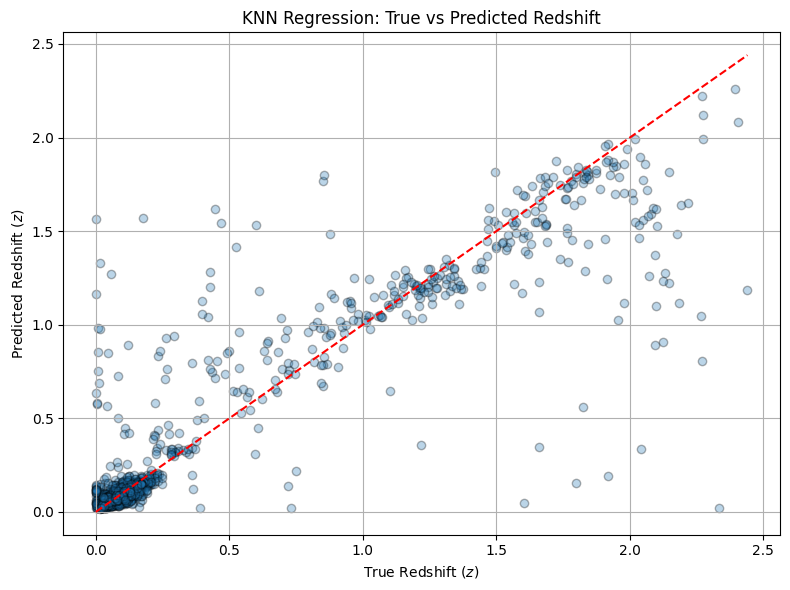

In [40]:
# Best model
best_knn = grid_search.best_estimator_
print("Best Parameters:")
print(grid_search.best_params_)

# Predict on test set
y_pred = best_knn.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTest Set Evaluation:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Plot: True vs Predicted Redshifts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, edgecolors='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel(r"True Redshift ($z$)")
plt.ylabel(r"Predicted Redshift ($z$)")
plt.title("KNN Regression: True vs Predicted Redshift")
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
# Get best parameters from grid search
knn_params = grid_search.best_params_

# Create a new RandomForestRegressor with the best params and the same random_state
knn_model = KNeighborsRegressor(**knn_params,)

# Retrain the model on the full training data
knn_model.fit(X_train, y_train)

# Predict on test set
y_pred = knn_model.predict(X_test)

# Evaluate predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Evaluation after retraining with best parameters:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")


Evaluation after retraining with best parameters:
R² Score: 0.8559
Mean Squared Error: 0.0294
Mean Absolute Error: 0.0555


In [42]:
# Save the KNN trained model to disk
knn_model_filename = "knn_model.pkl"
joblib.dump(knn_model, knn_model_filename)

['knn_model.pkl']

## Random Forest
Let's try for Random Forest Regressor, see <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html> for more details.

---

**中文**

## 随机森林
让我们尝试一下随机森林回归器，请参阅 <https://scikit-learn.org/stable/modules/ generated/sklearn.ensemble.RandomForestRegressor.html> 了解更多详细信息。


In [43]:
# Set up Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
}

# Cross-validation strategy (reproducible splits)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Grid search with multiple scoring metrics
scoring = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit='r2',         # refit based on R² score
    cv=cv,
    n_jobs=4,
    verbose=1
)

grid_search

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=4,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             refit='r2',
             scoring={'neg_mae': 'neg_mean_absolute_error',
                      'neg_mse': 'neg_mean_squared_error', 'r2': 'r2'},
             verbose=1)

In [44]:
# Start timing
start_time = time.time()

# Fit the model
grid_search.fit(X_train, y_train)

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nGrid search took {elapsed_time:.2f} seconds.")

Fitting 3 folds for each of 324 candidates, totalling 972 fits


/Users/user1/Data/brics_astro/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 972.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/user1/Data/brics_astro/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/user1/Data/brics_astro/.venv/lib/python3.10/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/user1/Data/brics_astro/.venv/lib/python3.10/site-packages/sklearn/base.py", line 436, in _validate_par


Grid search took 235.03 seconds.


Best Parameters Found:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Test Set Evaluation:
R² Score: 0.8515
Mean Squared Error (MSE): 0.0303
Mean Absolute Error (MAE): 0.0574


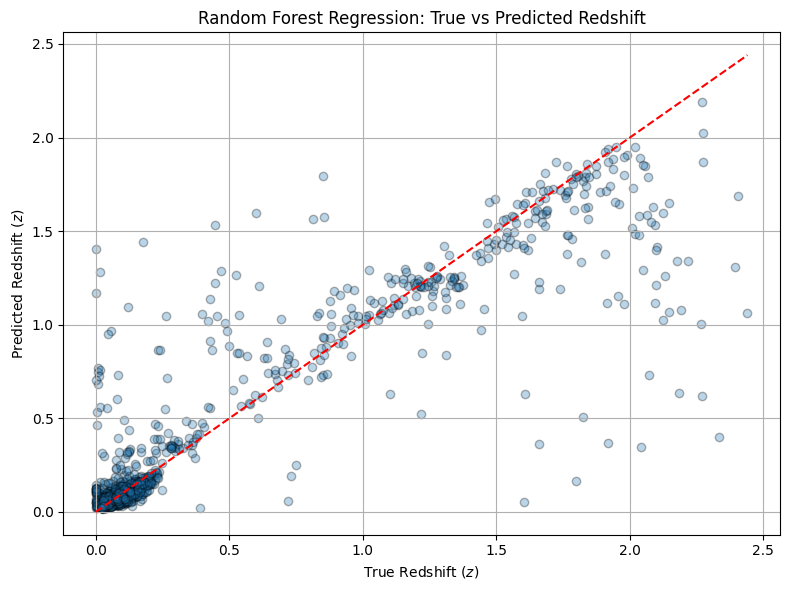

In [45]:
# Get best model
best_rf = grid_search.best_estimator_
print("Best Parameters Found:")
print(grid_search.best_params_)

# Evaluate on test set
y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTest Set Evaluation:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# 11. Plot: True vs Predicted Redshifts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, edgecolors='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel(r"True Redshift ($z$)")
plt.ylabel(r"Predicted Redshift ($z$)")
plt.title("Random Forest Regression: True vs Predicted Redshift")
plt.grid(True)
plt.tight_layout()
plt.show()


Bear in mind that the above will take some minutes to run.

---

**中文**

请记住，运行上述内容将需要几分钟的时间。


In [47]:
# Get best parameters from grid search
rf_params = grid_search.best_params_

# Create a new RandomForestRegressor with the best params and the same random_state
rf_model = RandomForestRegressor(**rf_params, random_state=42)

# Retrain the model on the full training data
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Evaluation after retraining with best parameters:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")


Evaluation after retraining with best parameters:
R² Score: 0.8515
Mean Squared Error: 0.0303
Mean Absolute Error: 0.0574


In [48]:

# 5. Save the trained model to disk
rf_model_filename = "rf_model.pkl"
joblib.dump(rf_model, rf_model_filename)

['rf_model.pkl']

The random forest model improved from 84% in the previous notebook to 85%.

---

**中文**

随机森林模型从之前笔记本中的 84% 提高到 85%。


## Summary

This section introduced the concept of hyper-parmater tuning for regression problems.


We briefly demonstrated a basic workflow using the **scikit-learn** library:
*   Loading the redshift dataset.
*   Splitting data into **training** and **test sets** to avoid overfitting and evaluate generalization.
*   Initialize (K-Nearest Neighbors and Random Forest) models.
*   Used **Hyperparameter Tuning** to optimize model performance and using **Grid Search** (`GridSearchCV`) to find the best parameters through systematic search and cross-validation on the training data.
*   Saved the trained models for future use.

**Additional Resources**

Scikit Learn cross validation: <https://scikit-learn.org/stable/modules/cross_validation.html>

Stratified K Fold: <https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right>

Cross Validation: <https://www.kaggle.com/code/azminetoushikwasi/ml-foundation-cross-validation-all-methods>

---

**中文**

## 总结

本节介绍了回归问题的超参数调整的概念。


我们简要演示了使用 **scikit-learn** 库的基本工作流程：
* 加载红移数据集。
* 将数据拆分为**训练**和**测试集**以避免过度拟合并评估泛化能力。
* 初始化（K 最近邻和随机森林）模型。
* 使用**超参数调优**来优化模型性能，并使用**网格搜​​索** (`GridSearchCV`) 通过对训练数据的系统搜索和交叉验证来找到最佳参数。
* 保存训练后的模型以供将来使用。

**额外资源**

Scikit Learn 交叉验证：<https://scikit-learn.org/stable/modules/cross_validation.html>

分层 K 折：<https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right>

交叉验证：<https://www.kaggle.com/code/azminetoushikwasi/ml-foundation-cross-validation-all-methods>
